In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df = pd.read_csv('C:\\Users\\dell\\Downloads\\archive (1)\\Social_Network_Ads.csv')

In [84]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [85]:
df.drop('User ID',axis=1,inplace=True)

In [86]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


## Feature engineering

In [87]:
dummies=pd.get_dummies(df['Gender'],dtype=int)

In [88]:
df=pd.concat([df,dummies],axis=1)

In [89]:
df.drop('Gender',axis=1,inplace=True)

In [90]:
df.head()

,Age,EstimatedSalary,Purchased,Female,Male
0,19,19000,0,0,1
1,35,20000,0,0,1
2,26,43000,0,1,0
3,27,57000,0,1,0
4,19,76000,0,0,1


In [91]:
df['Age'].unique()

array([19, 35, 26, 27, 32, 25, 20, 18, 29, 47, 45, 46, 48, 49, 31, 21, 28,
       33, 30, 23, 24, 22, 59, 34, 39, 38, 37, 42, 40, 36, 41, 58, 55, 52,
       60, 56, 53, 50, 51, 57, 44, 43, 54], dtype=int64)

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

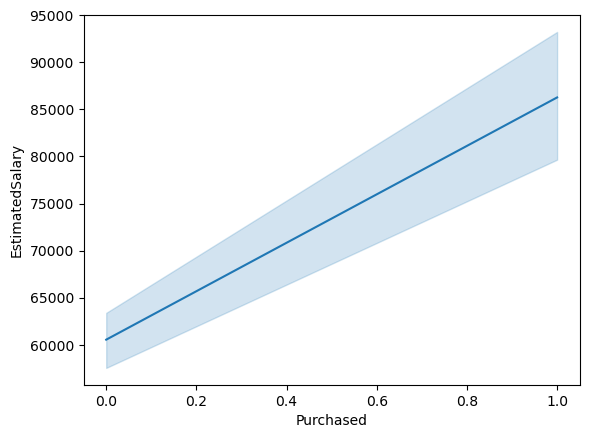

In [92]:
sns.lineplot(df,y='EstimatedSalary',x='Purchased')

In [93]:
df.corr()

,Age,EstimatedSalary,Purchased,Female,Male
Age,1.000000,0.155238,0.622454,0.073741,-0.073741
EstimatedSalary,0.155238,1.000000,0.362083,0.060435,-0.060435
Purchased,0.622454,0.362083,1.000000,0.042469,-0.042469
Female,0.073741,0.060435,0.042469,1.000000,-1.000000
Male,-0.073741,-0.060435,-0.042469,-1.000000,1.000000


<Axes: >

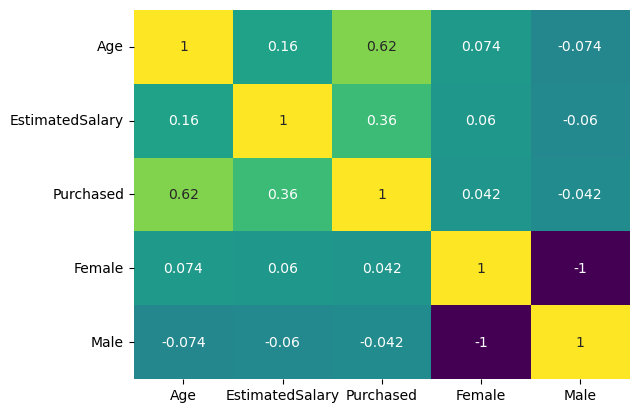

In [94]:
sns.heatmap(df.corr(),cmap='viridis',cbar=False,annot=True)

In [95]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
Female             0
Male               0
dtype: int64

In [96]:
X=df[['Age','EstimatedSalary','Female','Male']]

In [97]:
y=df['Purchased']

In [98]:
X.head()

,Age,EstimatedSalary,Female,Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,1,0
3,27,57000,1,0
4,19,76000,0,1


In [99]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

## scaling the numerical variables

In [100]:
from sklearn.preprocessing import MinMaxScaler

In [101]:
X=MinMaxScaler().fit_transform(X)

In [102]:
X = pd.DataFrame(X, columns=df.drop('Purchased', axis=1).columns)

In [103]:
X

,Age,EstimatedSalary,Female,Male
0,0.023810,0.029630,0.0,1.0
1,0.404762,0.037037,0.0,1.0
2,0.190476,0.207407,1.0,0.0
3,0.214286,0.311111,1.0,0.0
4,0.023810,0.451852,0.0,1.0
...,...,...,...,...
395,0.666667,0.192593,1.0,0.0
396,0.785714,0.059259,0.0,1.0
397,0.761905,0.037037,1.0,0.0
398,0.428571,0.133333,0.0,1.0


In [104]:
from sklearn.model_selection import train_test_split

In [105]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [107]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((280, 4), (120, 4), (280,), (120,))

In [108]:
from sklearn.linear_model import LogisticRegression

In [109]:
model  = LogisticRegression().fit(X_train,y_train)

In [110]:
preds = model.predict(X_test)

In [111]:
preds

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0], dtype=int64)

In [118]:
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score

In [123]:
rmse = np.sqrt(mean_squared_error(y_test,preds))

In [124]:
rmse

0.39791121287711073

In [125]:
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8416666666666667


In [126]:
from sklearn.tree import DecisionTreeClassifier

In [176]:
model  = DecisionTreeClassifier(
    max_depth=2,
    max_features='log2',
    random_state=42
).fit(X_train,y_train)

In [177]:
pred = model.predict(X_test)

In [178]:
pred

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0], dtype=int64)

In [179]:
rmse = np.sqrt(mean_squared_error(y_test,pred))
acc=accuracy_score(y_test, pred)

In [180]:
rmse,acc

(0.2581988897471611, 0.9333333333333333)